# (02) VIB: reduce to VAE, test

project = ```VIB```, host = ```mach```, device = ```cuda:2```

**Motivation**: <br>

The idea is to take rotating MNIST with both ```tau_context = tau_pred = 1```, and $\theta_0 = \theta = 0$. Then, you're basically doing a VAE with a linear encoder and decoder. This should work as good as ```<lin|lin>``` P-VAE. Good starting point.

In [1]:
# HIDE CODE


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-progress-2025/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-progress-2025/figs')
tmp_dir = os.path.join(git_dir, 'jb-progress-2025/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, '_VIB'))
# from analysis.eval import sparse_score
from figures.fighelper import *
from main.train_vib import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
from figures.imgs import plot_weights


device_idx = 2
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:2  ———  host: mach

## Trainer

In [3]:
model_type = 'poisson'

cfg = CFG_CLASSES[model_type](
    n_latents=2048,
    dataset='RotatingMNIST',
    kws_data={'theta_0': 0, 'delta_theta': 0},
    tau_context=1,
    tau_pred=1,
)

tr = TrainerVIB(
    model=MODEL_CLASSES[model_type](cfg),
    cfg=ConfigTrainVIB(batch_size=200, epochs=100, kl_beta=1.0),
    device=device,
)

# cfg_vae, cfg_tr = default_configs('EyeMovies16', model_type, 'lin|lin')

In [4]:
tr.model.print()

+-------------+------------+
| Module Name | Num Params |
+-------------+------------+
|  PoissonVIB |  3.2 Mil   |
|     ———     |    ———     |
|    layer    |  1.6 Mil   |
|     dec     |  1.6 Mil   |
+-------------+------------+

In [5]:
print(tr.model.layer)

PoissonLayer(tau=[1,1], temp=1, beta=1)

In [6]:
print_num_params(tr.model.layer.enc.conv_t)
print_num_params(tr.model.layer.enc.conv_s)

+-------------+------------+
| Module Name | Num Params |
+-------------+------------+
|    Conv2D   |   4.1 K    |
|     ———     |    ———     |
|    _layer   |   4.1 K    |
+-------------+------------+

+-------------+------------+
| Module Name | Num Params |
+-------------+------------+
|    Conv2D   |  1.6 Mil   |
|     ———     |    ———     |
|    _layer   |  1.6 Mil   |
+-------------+------------+

### Test the dataset

In [7]:
x, y, g = next(iter(tr.dl_vld))
x.shape, y.shape, g.shape

(torch.Size([200, 1, 28, 28]), torch.Size([200, 1, 28, 28]), torch.Size([200]))

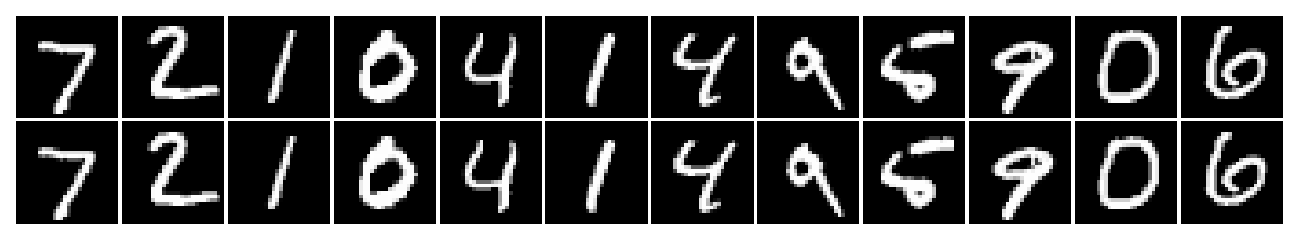

In [8]:
num = 12
x2p = torch.cat([x[:num], y[:num]])

_ = plot_weights(x2p.squeeze(), method='none', nrows=2)

In [9]:
torch.abs(x - y).sum()

tensor(0., device='cuda:1')

## Fit

In [10]:
tr.train()

epoch # 100, avg loss: 40.956226: 100%|█████| 100/100 [1:15:47<00:00, 45.48s/it]


In [11]:
x, y, *_ = next(iter(tr.dl_vld))
output = tr.model(x, y.flatten(start_dim=1))

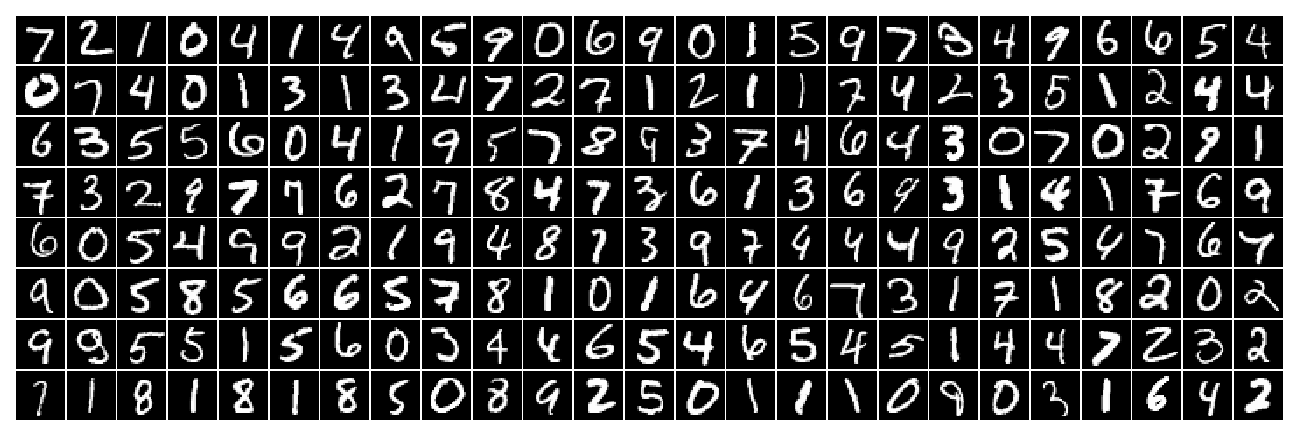

In [12]:
_ = plot_weights(y.squeeze(), method='none', nrows=8)

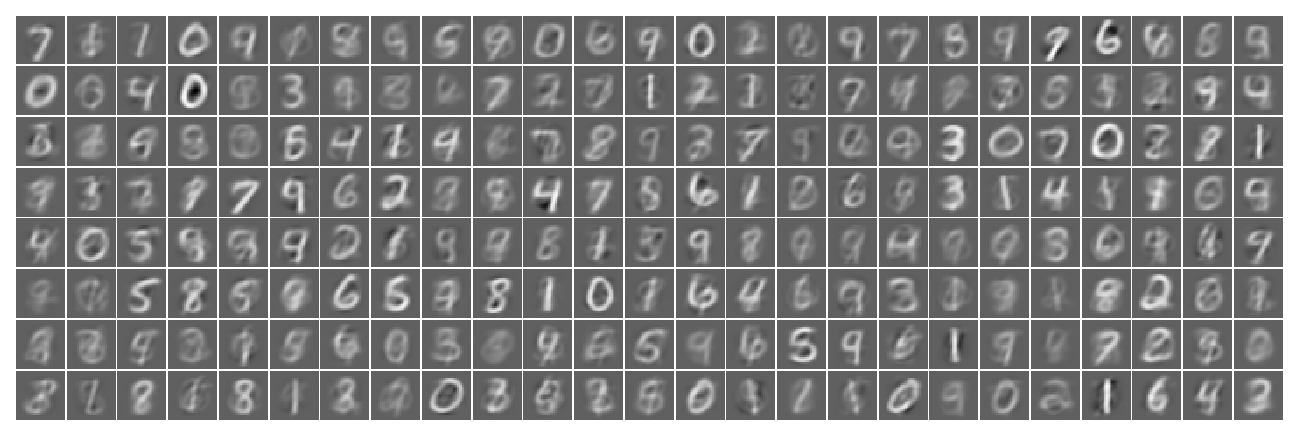

In [13]:
pred = output['conditional'].loc
shape = (-1, tr.model.cfg.npix, tr.model.cfg.npix)
_ = plot_weights(pred.reshape(shape), method='none', nrows=8)

In [14]:
print(tr.model.layer)

PoissonLayer(tau=[1,1], temp=0.05, beta=1)

In [15]:
data, loss, etc = tr.forward('vld')

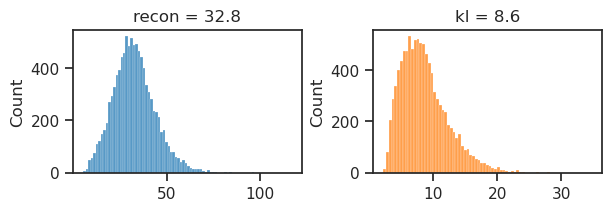

In [16]:
fig, axes = create_figure(1, 2)

sns.histplot(loss['recon'], ax=axes[0])
axes[0].set_title(f"recon = {loss['recon'].mean():0.1f}")

sns.histplot(loss['kl'], color='C1', ax=axes[1])
axes[1].set_title(f"kl = {loss['kl'].mean():0.1f}")

plt.show()

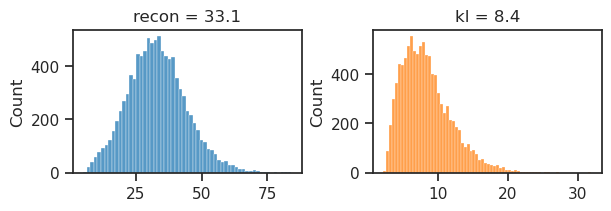